Ans 1: Fundamental idea behind ensemble techniques is that ensemble techniques combine multiple individual (weak or base) models to create a stronger overall model. The idea here is that group of models when combined can correct each other's and produce better accuracy, stability and generalization compared to a single model.
It is just like taking the wisdom of the crowd.

Differences between Bagging (Bootstrap Aggregating) and Boosting in terms of approach and objectives is listed below:-
* Bagging trains many models independently and in parallel whereas Boosting trains models sequentially, one after another.
* In Bagging, each model is trained on a random sample with replacement (bootstrap samples) whereas in Boosting, each model focuses more on the mistakes made by previous models.
* In Bagging, all models get equal weight in the final prediction whereas in Boosting models get different weights based on performance.
* Bagging reduces variance and prevents overfitting whereas Boosting reduces Bias and improves and accuracy by making later models more accurate than the previous ones.
* Bagging works best with high variance and unstable models like Decision Trees whereas Boosting works by creating a strong model from many weak learners.
* Examples of Bagging are Random Forest and Bagging Classifier.                 Examples of Boosting are: Adaboost, Gradient Boosting, XG Boost, etc.





Ans 2: In Random Forest Classifier, a single Decision Tree tends to overfit because it keeps splitting until it perfectly fits the training data — capturing noise along with the patterns.

The Random Forest Classifier, hoowever as a result, random errors and noise get canceled out.educes overfitting using Ensemble Learning and i.e., by the following:
* It builds many decision trees on different subsets of data & features
* The final prediction is made by majority voting (classification) or averaging (regression).
* As a result, random errors and noise get canceled out.

**Role Of the Two Key Hyperparameters in this Prooces:**
1. n estimators (number of Trees):- More Trees give better averaging but lower variance. Each tree might overfit on its own, but averaging many overfitted trees reduces overall overfitting and after a point adding more trees gives diminishing returns
2. Max features (no. of features considered at each split node): This forces trees to look at different subsets of features. This increases the diversity between the trees or (decorrelation). If all trees used all features, they would become similar and overfit together. Lower max features results in higher randomness and less overfitting.



Ans 3: Stacking (Stacked Generalization) is an ensemble technique where multiple different models (Level-1 models) are trained, and then a meta-model (Level-2 model) is trained on their predictions to produce the final output.

The idea here is:-
* Each model learns different patterns
* The meta-model learns how to combine them for best performances.

Stacking differs from Bagging and Boosting in different ways:-
1. Bagging trains same models on different Bootstrap samples whereas Boosting trains different types of models sequentially correcting previous errors but in Stacking, different types of models are trained parallely.
2. Bagging combines results by averaging/voting whereas Boosting combines by weighted sums (focusing just on the hard examples). and in Stacking a meta-learner is used to combine predictions, more flexible and powerful.
3. Bagging reduces variance whereas Boosting reduces bias but Stacking reduces bpth by leveraging diversity.


Ans 4: OOB (Out-Of-Bag) Score is an internal validation score used in Random Forest. When each decision tree is trained using bootstrap sampling, about one-third of the data is left out (not selected). These leftover samples are called Out-Of-Bag samples. Each tree predicts the labels of its own OOB samples, and the combined accuracy from all trees gives the OOB Score.

It is useful due to the following reasons:-
* It provides a built-in performance estimate, similar to validation accuracy.
* It helps check how well the model generalizes without needing extra validation data.
* It saves data:- useful especially for a small dataset.

This helps in model evaluation without a validation set because of the following:
1. Every tree gets its own set of OOB samples
2. These samples act like mini-validation sets.
3. Predictions from all trees are aggregated.
4. The results are reliable estimates of model performance.

Ans 5: **Handling Errors from Weak Learners:-**
* Adaboost mainly focuses on misclassified samples whereas Gradient Boosting models the errors/residuals directly.
* Adaboost increases the weights of the misclassified points after each weak learner, so that the next learner tries harder on those tricks whereas the Gradient Booster fits a new model to the residuals (difference between predicted & actual values) after each weak learner.
* In Adaboost, each model gets influenced by how many points it gets wrong i.e., the Sample-weight-driven correction whereas Gradient Booster corrects mistakes via a gradient of a loss function not by changing sample weights.

**Adjusting Weights:-**
* In Adaboost, each training model has a weight which is misclassified as = weight >, correctly classified as weight < whereas in Gradient Boosting there are no sample weights.
* Gradient Boosting uses gradient descent to minimize the loss function
* In Adaboost, the final model is a weighted sum of weak learners whereas Gradient Booster adds weak learners as 'correlations' to the previous errors.
* In Adaboost weighing is explicit whereas in Gradient Boosting weighting is implicit through the Gradient.

**Typical Used Cases:-**
* Adaboost works well with clean, low-noise dor tabular data whereas Gradient Boosting is great for complex patterns & harder problems
* Adaboost is often used with weak learners like decision stumps (1-level trees) whereas Gradient booster is used in many top ML solutions, for eg:- XG Boost & Light GBM.
* Adaboost is faster & simpler whereas Gradient Booster is flexible & supports different loss functions (Regression, Classification and Ranking).


Ans 6: CatBoost performs well on categorial data because it doesn't need one-hot encoding or heavy preprocessing. Instead, it uses two smart techniques:
1. **Ordered Target Encoding (with permutations):-** For each categorial feature, Catboost converts categories into numerical statistics based on the target, but with a twist:-
* It processes data in random permutations.
* For each row, CatBoost uses only previous rows to calculate the statistics (Mean Target Value)
* This avoids target leakage, which is the main problem with normal target encoding.
* This is good to use because it gives Catboost meaningful numeric representations of categories without overfitting
2. **One-Hot Encodingvonly for rare categories:-** If a category appears very few times, CatBoost applies single one-hot encoding just for those rare values. It is good to use because it prevents noise from uncommon categories.

CatBoost handles categorial values natively by using ordered targret encoding + smart one-hot encoding giving strong performance without manual preprocessing.

Ans 7:

In [1]:
#KNN Classifier:- Wine data anaysis + Optimization
# KNN Classifier Assignment: Wine Dataset Analysis with Optimization

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# -----------------------------
# 1. Load Wine Dataset
# -----------------------------
data = load_wine()
X = data.data
y = data.target

# -----------------------------
# 2. Train–Test Split (70–30)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# -----------------------------
# 3. KNN without Scaling
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred1 = knn.predict(X_test)

print("\n=== KNN WITHOUT SCALING ===")
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("\nClassification Report:\n", classification_report(y_test, y_pred1))

# -----------------------------
# 4. Apply Scaling + Retrain KNN
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred2 = knn_scaled.predict(X_test_scaled)

print("\n=== KNN WITH STANDARD SCALING ===")
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("\nClassification Report:\n", classification_report(y_test, y_pred2))

# -----------------------------
# 5. GridSearchCV for Best K and Distance Metric
# -----------------------------
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("\n=== GRID SEARCH RESULTS ===")
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# -----------------------------
# 6. Train Optimized KNN
# -----------------------------
best_knn = grid.best_estimator_
y_pred3 = best_knn.predict(X_test_scaled)

print("\n=== OPTIMIZED KNN ===")
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("\nClassification Report:\n", classification_report(y_test, y_pred3))

# -----------------------------
# Summary Comparison
# -----------------------------
print("\n=== SUMMARY COMPARISON ===")
print(f"Unscaled KNN Accuracy:  {accuracy_score(y_test, y_pred1):.4f}")
print(f"Scaled KNN Accuracy:    {accuracy_score(y_test, y_pred2):.4f}")
print(f"Optimized KNN Accuracy: {accuracy_score(y_test, y_pred3):.4f}")


=== KNN WITHOUT SCALING ===
Accuracy: 0.7222222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        18
           1       0.78      0.67      0.72        21
           2       0.50      0.60      0.55        15

    accuracy                           0.72        54
   macro avg       0.72      0.72      0.72        54
weighted avg       0.74      0.72      0.73        54


=== KNN WITH STANDARD SCALING ===
Accuracy: 0.9444444444444444

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.86      0.92        21
           2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54


=== GRID SEARCH RESULTS ===
Best Parameters: {'metric': 'euclidea

Ans 8:

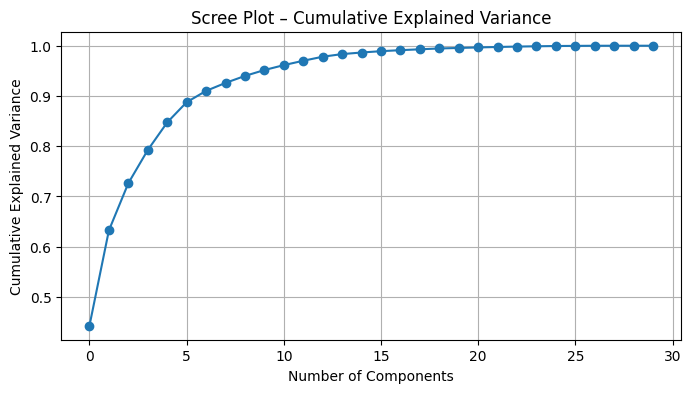

Original Shape: (569, 30)
PCA Shape (95% variance): (569, 10)

Accuracy (Original Data): 0.9707602339181286
Accuracy (PCA 95% Variance): 0.9473684210526315


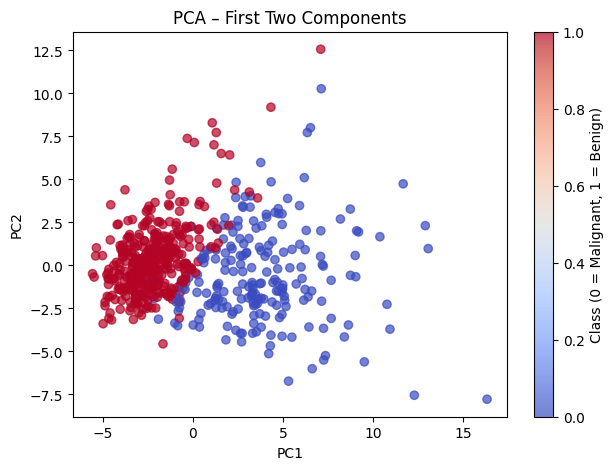

In [2]:
#Applying PCA and training KNN on original and PCA-transfornmed data to compare accuracy
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# ---------------------------------------------------------
# 1. Load Breast Cancer Dataset
# ---------------------------------------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Scale the data (important for PCA + KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# 2. PCA – Scree Plot (Explained Variance Ratio)
# ---------------------------------------------------------
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.title("Scree Plot – Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 3. Retain 95% Variance
# ---------------------------------------------------------
pca_95 = PCA(n_components=0.95)
X_pca = pca_95.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("PCA Shape (95% variance):", X_pca.shape)

# ---------------------------------------------------------
# 4. Train KNN on Original + PCA data
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

# KNN on original data
knn_orig = KNeighborsClassifier(n_neighbors=5)
knn_orig.fit(X_train, y_train)
y_pred_orig = knn_orig.predict(X_test)
acc_orig = accuracy_score(y_test, y_pred_orig)

# Train-test split for PCA data
X_train_p, X_test_p, _, _ = train_test_split(
    X_pca, y, test_size=0.30, random_state=42, stratify=y
)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_p, y_train)
y_pred_pca = knn_pca.predict(X_test_p)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("\nAccuracy (Original Data):", acc_orig)
print("Accuracy (PCA 95% Variance):", acc_pca)

# ---------------------------------------------------------
# 5. Scatter Plot – First Two Principal Components
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)
plt.title("PCA – First Two Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class (0 = Malignant, 1 = Benign)")
plt.show()

Ans 9:


=== MSE Comparison ===
Euclidean (K=5): 4960.896156409522
Manhattan (K=5): 5318.950055352522


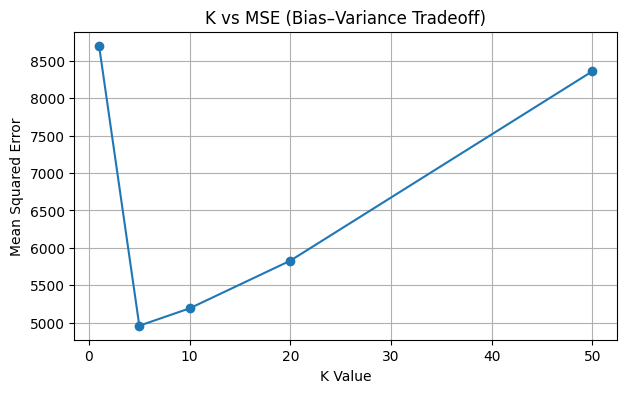


K vs MSE:
K=1: MSE=8699.684834236592
K=5: MSE=4960.896156409522
K=10: MSE=5193.088340754034
K=20: MSE=5829.390080140192
K=50: MSE=8357.287493055552


In [3]:
#KNN Regressor- Distance Metrics + K-value Analysis
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------
# 1. Generate Synthetic Regression Dataset
# ---------------------------------------------------
X, y = make_regression(
    n_samples=500,
    n_features=10,
    noise=15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# ---------------------------------------------------
# 2. KNN Regressor (Euclidean vs Manhattan)
# ---------------------------------------------------

# (a) Euclidean distance
knn_euclidean = KNeighborsRegressor(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
y_pred_euc = knn_euclidean.predict(X_test)
mse_euc = mean_squared_error(y_test, y_pred_euc)

# (b) Manhattan distance
knn_manhattan = KNeighborsRegressor(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_man = knn_manhattan.predict(X_test)
mse_man = mean_squared_error(y_test, y_pred_man)

print("\n=== MSE Comparison ===")
print("Euclidean (K=5):", mse_euc)
print("Manhattan (K=5):", mse_man)

# ---------------------------------------------------
# 3. Bias–Variance Analysis (K vs. MSE)
# ---------------------------------------------------
K_values = [1, 5, 10, 20, 50]
mse_list = []

for k in K_values:
    knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    mse_list.append(mean_squared_error(y_test, pred))

# Plot K vs MSE
plt.figure(figsize=(7, 4))
plt.plot(K_values, mse_list, marker='o')
plt.title("K vs MSE (Bias–Variance Tradeoff)")
plt.xlabel("K Value")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

print("\nK vs MSE:")
for k, m in zip(K_values, mse_list):
    print(f"K={k}: MSE={m}")

Ans 10:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== KNN Results by 

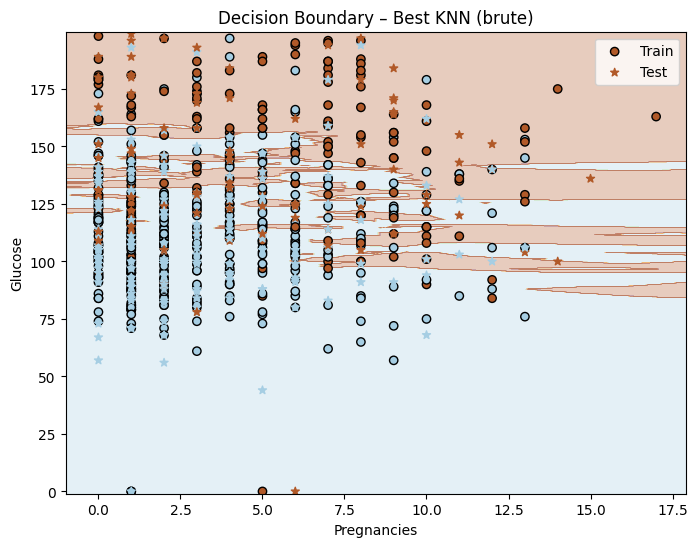

In [4]:
#Code
import time
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Load the dataset
url = "https://raw.githubusercontent.com/MasteriNeuron/datasets/refs/heads/main/diabetes.csv"
df = pd.read_csv(url)

# Show first few rows
print(df.head())
print(df.isnull().sum())

# 2. KNN Imputation
imputer = KNNImputer(n_neighbors=5)
X = df.drop("Outcome", axis=1)  # assuming the target column is "Outcome"
y = df["Outcome"]

X_imputed = imputer.fit_transform(X)

# 3. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

# Prepare different KNNs
algorithms = ["brute", "kd_tree", "ball_tree"]
results = {}

for algo in algorithms:
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)

    start = time.time()
    knn.fit(X_train, y_train)
    end = time.time()

    train_time = end - start
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results[algo] = {"time": train_time, "accuracy": acc}

# Print results
print("\n=== KNN Results by Algorithm ===")
for algo, res in results.items():
    print(f"{algo}: Train time = {res['time']:.4f} s, Accuracy = {res['accuracy']:.4f}")

# 5. Decision Boundary for Best Model
best_algo = max(results, key=lambda x: results[x]["accuracy"])
print("\nBest algorithm:", best_algo)

# Let's pick two most important features manually or by domain knowledge:
# For demonstration, pick first two columns (you can change this)
feature_idx = [0, 1]
X2 = X_imputed[:, feature_idx]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y
)

best_knn = KNeighborsClassifier(n_neighbors=5, algorithm=best_algo)
best_knn.fit(X2_train, y2_train)

# Create meshgrid for plotting decision boundary
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)
Z = best_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, edgecolor="k", cmap=plt.cm.Paired, label="Train")
plt.scatter(X2_test[:, 0], X2_test[:, 1], c=y2_test, marker="*", cmap=plt.cm.Paired, label="Test")
plt.xlabel(df.columns[feature_idx[0]])
plt.ylabel(df.columns[feature_idx[1]])
plt.title("Decision Boundary – Best KNN (" + best_algo + ")")
plt.legend()
plt.show()